In [ ]:
import sys; sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import prepare
from src.features import add_lag_rolling_features, add_calendar_price_feature

ImportError: cannot import name 'prepare' from 'src.data' (/Users/jay/Documents/Project 2/demand_forecast_inventory_optimizer/notebooks/../src/data.py)

In [ ]:
sales_tidy = prepare(stores=["CA_1"], category="FOODS")
print(sales_tidy['cat_id'].unique())     # ['FOODS']
print(sales_tidy['id'].nunique())          # 1437

In [ ]:
zero_fraction = (sales_tidy['sales'] == 0).mean()
print(f"Zero-sales days: {zero_fraction:.1%}")
print(sales_tidy['sales'].describe())

Zero-sales days: 56.9%
count    2.789217e+06
mean     1.961719e+00
std      5.379334e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      6.480000e+02
Name: sales, dtype: float64


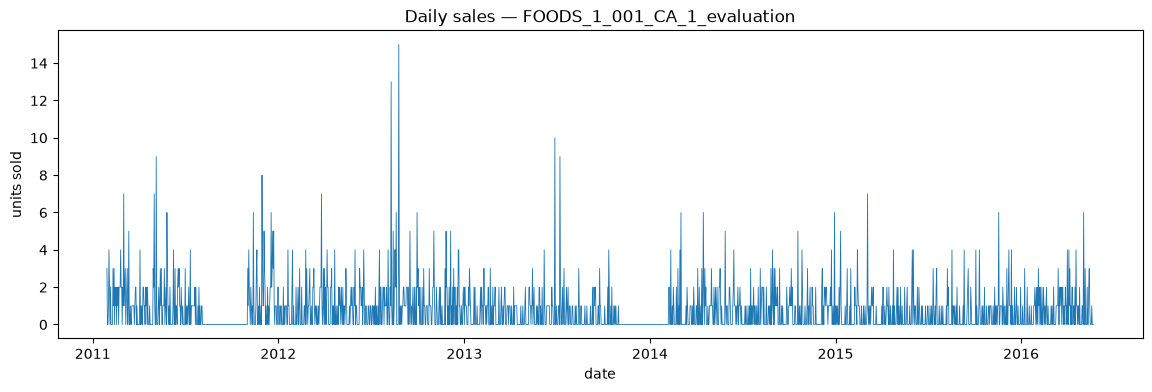

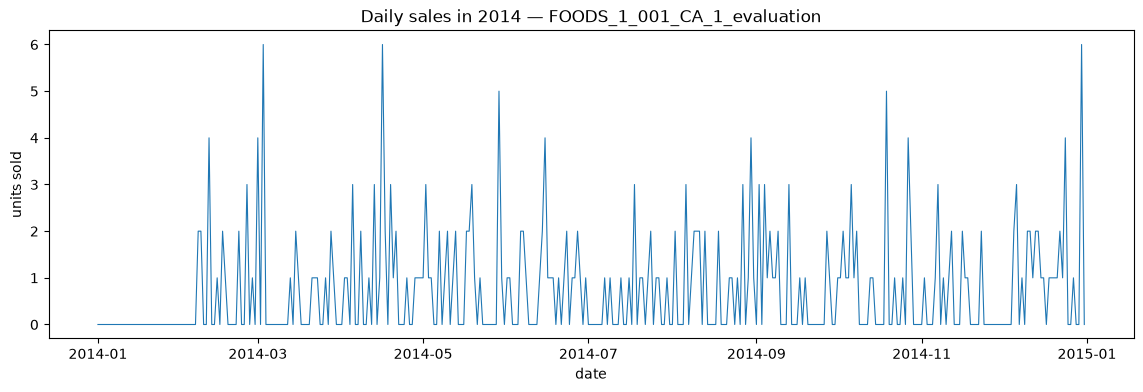

In [ ]:
import matplotlib.pyplot as plt

# ── 1. Intermittency ─────────────────────────────────────────────
zero_fraction = (sales_tidy['sales'] == 0).mean()
print(f"Zero-sales days: {zero_fraction:.1%}")
print(sales_tidy['sales'].describe())

# ── 2. Single-product plot ───────────────────────────────────────
one_id = sales_tidy['id'].unique()[0]          # pick the first product
subset = sales_tidy[sales_tidy['id'] == one_id]

# full history
plt.figure(figsize=(14, 4))
plt.plot(subset['date'], subset['sales'], linewidth=0.6)
plt.title(f"Daily sales — {one_id}")
plt.xlabel("date"); plt.ylabel("units sold")
plt.show()

# one year, easier to read weekly pattern
subset_2014 = subset[subset['year'] == 2014]
plt.figure(figsize=(14, 4))
plt.plot(subset_2014['date'], subset_2014['sales'], linewidth=0.8)
plt.title(f"Daily sales in 2014 — {one_id}")
plt.xlabel("date"); plt.ylabel("units sold")
plt.show()

In [ ]:
# Sales by department and series count
print("Departments:",sales_tidy['dept_id'].unique())
print("Series:", sales_tidy['id'].nunique())
print("Average Sales by Department:")
print(sales_tidy.groupby('dept_id')['sales'].mean())

# Effect of weekday on sales
print("\nMean sales by weekday ( 1= Satuday, 7= Friday):")
print(sales_tidy.groupby('wday')['sales'].mean())

# Effect of any events on sales
sales_tidy['is_event'] = sales_tidy['event_name_1'].notnull() | sales_tidy['event_name_2'].notnull()
print("\nMean sales on event days vs non-event days:")
print(sales_tidy.groupby('is_event')['sales'].mean())

# Correlation of price vs sales
print("\nCorrelation of price vs sales:")
print(sales_tidy[['sell_price', 'sales']].corr().iloc[0, 1])

# SNAP effect (CA_1 store -> snap_CA) 
print("\nMean sales by SNAP day (CA):")
print(sales_tidy.groupby('snap_CA')['sales'].mean())

Departments: ['FOODS_1' 'FOODS_2' 'FOODS_3']
Series: 1437
Average Sales by Department:
dept_id
FOODS_1    1.377287
FOODS_2    1.165528
FOODS_3    2.500142
Name: sales, dtype: float64

Mean sales by weekday ( 1= Satuday, 7= Friday):
wday
1    2.458151
2    2.521833
3    1.878550
4    1.655995
5    1.613957
6    1.634427
7    1.965308
Name: sales, dtype: float64

Mean sales on event days vs non-event days:
is_event
False    1.969130
True     1.878095
Name: sales, dtype: float64

Correlation of price vs sales:
-0.1531261546495146

Mean sales by SNAP day (CA):
snap_CA
0    1.887244
1    2.113113
Name: sales, dtype: float64


## Data notes

**Subset.** Scoped to the FOODS category in store CA_1 — 1,437 product-store
series over ~1,941 days (full history kept). FOODS chosen for the richest,
most regular demand; single store keeps the problem tractable for the window.

**Intermittency.** 56.9% of all product-days have zero sales. The sales
distribution is heavily right-skewed (median 0, 75th percentile 2, max 648,
std ≈ 3× the mean). This is lumpy, intermittent demand.

**Implication for metrics.** Because actuals are zero 57% of the time, MAPE is
undefined / explodes (division by zero). We therefore evaluate with MASE and
pinball loss, not MAPE. The skew also motivates forecasting a *distribution*
(prediction intervals) rather than a single point.

**Leading zeros.** Long runs of zeros at the start of a series typically mean
the product was not yet stocked, not that demand was zero. [TODO: confirm from
your single-product plot — did you see this?]

**Signals worth featurising** (from the effects analysis):
- Weekday: weekend ~50% higher than midweek — strong signal.
- SNAP: ~12% higher on SNAP days — real, keep it.
- Price: −0.15 correlation, correct direction, modest.
- Events: flat/slightly negative as a single flag, because event types conflict — consider encoding type rather than presence.

In [ ]:
sales_feat = add_lag_rolling_features(sales_tidy)
sales_feat = add_calendar_price_feature(sales_feat)

In [ ]:
feature_cols = (
    ['lag_7', 'lag_14', 'lag_28',
     'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28',
     'day', 'is_event', 'snap', 'sell_price']
)
model_df = sales_feat.dropna(subset=feature_cols).reset_index(drop=True)
print(f"{len(model_df):,} rows after dropping warm-up/missing")

model_df.to_parquet('../data/model_df.parquet')   # handoff to notebook 02